# Zero-shot → Few-shot → LoRA Fine-tuning

In this notebook, we'll explore three different approaches to text classification:
1. **Zero-shot**: Using a pre-trained model with no training data
2. **Few-shot**: Providing examples in the prompt
3. **LoRA Fine-tuning**: Training a small adapter (Parameter-Efficient Fine-Tuning)

**Task**: Sentiment Analysis on Movie Reviews (IMDB Dataset)


---

## Setup & Installation

First, let's install the required libraries. These are the main tools we'll use:
- **transformers**: The core library for working with pre-trained models
- **peft**: Parameter-Efficient Fine-Tuning library (includes LoRA, DoRA, etc.)
- **datasets**: Easy access to thousands of datasets
- **accelerate**: Helps with training on different hardware

In [ ]:
# Install required packages
!pip install -q transformers peft datasets accelerate evaluate scikit-learn matplotlib
!pip install -U bitsandbytes>=0.46.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00


In [ ]:
# Import all the libraries we need
import torch
from transformers import (
    AutoTokenizer,                    # Converts text to numbers the model understands
    AutoModelForSequenceClassification, # Pre-trained model for classification
    TrainingArguments,                 # Settings for training
    Trainer                            # Handles the training loop
)
from datasets import load_dataset
from peft import LoraConfig, get_peft_model, TaskType
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Check if GPU is available (makes training faster)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device}")
if device == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

 Using device: cuda
   GPU: Tesla T4


## Load & Prepare Dataset

We'll use the IMDB movie review dataset:
- **25,000 training reviews** (positive/negative)
- **25,000 test reviews**

We'll use a **smaller subset** to keep training fast.

In [ ]:
# Load IMDB dataset from Hugging Face
print("Loading IMDB dataset...")
dataset = load_dataset("imdb")


train_dataset = dataset["train"].shuffle(seed=42).select(range(1000))  # 1000 examples
test_dataset = dataset["test"].shuffle(seed=42).select(range(500))     # 500 examples

print(f"Training examples: {len(train_dataset)}")
print(f"Test examples: {len(test_dataset)}")
print(f"\n Sample review:\n{train_dataset[0]['text'][:200]}...")
print(f"\n Label: {'Positive' if train_dataset[0]['label'] == 1 else 'Negative'}")

Loading IMDB dataset...


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Training examples: 1000
Test examples: 500

 Sample review:
There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F...

 Label: Positive


##  Zero-Shot Classification

**What is Zero-Shot?**
- Use the model "as-is" without any training
- The model uses its general knowledge from pre-training
- Fast but might not be very accurate for specific tasks

In [ ]:
# Load a small pre-trained model (DistilBERT - 66M parameters)
# DistilBERT is a smaller, faster version of BERT
model_name = "distilbert-base-uncased"
print(f"Loading model: {model_name}")

# Create a tokenizer specifically for the DistilBERT zero-shot model
tokenizer = AutoTokenizer.from_pretrained(model_name)

# For zero-shot, we use a model already trained on sentiment
# This simulates "zero-shot" relative to our specific IMDB data
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased"  # Pre-trained on sentiment
).to(device)

print(" Zero-shot model loaded!")

Loading model: distilbert-base-uncased


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Zero-shot model loaded!


In [ ]:
# Test zero-shot performance on a few examples
def predict_sentiment(text, model, tokenizer_for_model):
    """Helper function to predict sentiment of a single text"""
    inputs = tokenizer_for_model(text, return_tensors="pt", truncation=True, max_length=512).to(device)
    with torch.no_grad():  # Don't compute gradients (saves memory)
        outputs = model(**inputs)
        prediction = torch.argmax(outputs.logits, dim=-1).item()
    return prediction

# Test on a few examples
print("\n Testing Zero-Shot predictions:\n")
for i in range(3):
    text = test_dataset[i]['text'][:200]  # First 200 characters
    true_label = test_dataset[i]['label']
    # Use the zero_shot_tokenizer for the zero_shot_model
    pred_label = predict_sentiment(text, model, tokenizer)

    print(f"Example {i+1}:")
    print(f"Text: {text}...")
    print(f"True: {'Positive' if true_label == 1 else 'Negative'}")
    print(f"Predicted: {'Positive' if pred_label == 1 else 'Negative'}")
    print(f"{' Correct!' if pred_label == true_label else ' Wrong'}\n")


 Testing Zero-Shot predictions:

Example 1:
Text: <br /><br />When I unsuspectedly rented A Thousand Acres, I thought I was in for an entertaining King Lear story and of course Michelle Pfeiffer was in it, so what could go wrong?<br /><br />Very quic...
True: Positive
Predicted: Positive
 Correct!

Example 2:
Text: This is the latest entry in the long series of films with the French agent, O.S.S. 117 (the French answer to James Bond). The series was launched in the early 1950's, and spawned at least eight films ...
True: Positive
Predicted: Positive
 Correct!

Example 3:
Text: This movie was so frustrating. Everything seemed energetic and I was totally prepared to have a good time. I at least thought I'd be able to stand it. But, I was wrong. First, the weird looping? It wa...
True: Negative
Predicted: Positive
 Wrong



In [ ]:
print("Evaluating zero-shot performance on 500 test examples...")
zero_shot_predictions = []
for example in test_dataset:

    pred = predict_sentiment(example['text'], model, tokenizer)
    zero_shot_predictions.append(pred)

zero_shot_accuracy = accuracy_score(test_dataset['label'], zero_shot_predictions)
print(f"\n Zero-Shot Accuracy: {zero_shot_accuracy:.2%}")

Evaluating zero-shot performance on 500 test examples...

 Zero-Shot Accuracy: 50.20%


## Few-Shot Learning

**What is Few-Shot?**
- Provide a few examples in the prompt to guide the model
- No training required, just clever prompting
- Works better than zero-shot for specific tasks

**Note**: For classification models like DistilBERT, few-shot is simulated by showing examples. For generative models (like GPT), you'd include examples in the prompt.

In [ ]:
# In practice, this is more effective with generative models (GPT-style)

print("\nFew-Shot Concept:")
print("For generative models, you would provide examples like:")
print("\nExample 1: 'This movie was amazing!' → Positive")
print("Example 2: 'Terrible waste of time.' → Negative")
print("Now classify: 'I loved every minute!'")
print("\nFor our classification model, we'll move directly to fine-tuning...")


 Few-Shot Concept:
For generative models, you would provide examples like:

Example 1: 'This movie was amazing!' → Positive
Example 2: 'Terrible waste of time.' → Negative
Now classify: 'I loved every minute!'

For our classification model, we'll move directly to fine-tuning...


## LoRA Fine-Tuning

**What is LoRA (Low-Rank Adaptation)?**
- Instead of updating all model weights (millions of parameters), LoRA adds small "adapter" layers
- **Memory efficient**: Only ~0.1-1% of parameters are trained
- **Fast**: Training is much quicker than full fine-tuning
- **Modular**: You can swap adapters for different tasks

### How LoRA Works (Simplified)
```
Original model:  W  (frozen, not updated)
LoRA adds:       ΔW = A × B  (tiny matrices we train)
Final output:    W + ΔW
```

**Key Parameters**:
- `r` (rank): Size of the adapter (typical: 8-64). Smaller = fewer parameters
- `lora_alpha`: Scaling factor (typical: 16-32)
- `target_modules`: Which layers to adapt (e.g., attention layers)

In [ ]:
# Step 1: Load base model for training
print("Loading base model for LoRA fine-tuning...")
base_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
).to(device)

# Check how many parameters the model has
total_params = sum(p.numel() for p in base_model.parameters())
print(f" Base model parameters: {total_params:,}")

Loading base model for LoRA fine-tuning...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Base model parameters: 66,955,010


In [ ]:
# Step 2: Configure LoRA
# These settings control how LoRA adapts the model

lora_config = LoraConfig(
    r=16,                          # Rank size of the adapter matrices (higher = more capacity)
    lora_alpha=32,                 # Scaling factor (typically 2x the rank)
    target_modules=["q_lin", "v_lin", "k_lin", "out_lin", "ffn.lin1", "ffn.lin2"],
    lora_dropout=0.05,             # Dropout for regularization
    bias="none",                   # Don't adapt bias terms
    task_type=TaskType.SEQ_CLS     # Task type: Sequence Classification
)


# Step 3: Create PEFT model (adds LoRA adapters)
peft_model = get_peft_model(base_model, lora_config)

# See how many parameters we're actually training
peft_model.print_trainable_parameters()

trainable params: 1,919,234 || all params: 68,874,244 || trainable%: 2.7866


>We are training only ~3% of the total parameters

In [ ]:
# Step 4: Prepare data for training
# The model needs tokenized input

def tokenize_function(examples):
    """Convert text to tokens that the model can understand"""
    return tokenizer(
        examples["text"],
        padding="max_length",       # Pad to same length
        truncation=True,
        max_length=512              # Maximum sequence length
    )


print("Tokenizing datasets...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)
print("Tokenization complete!")

Tokenizing datasets...


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Tokenization complete!


In [ ]:
# Step 5 and 6: Define Training Arguments for the PEFT trainer, and the Metrics for Evaluation
training_args = TrainingArguments(
    output_dir="./lora_sentiment",
    num_train_epochs=5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,           # How many examples per evaluation step
    learning_rate=1e-4,                      # How fast the model learns (higher = faster but less stable)
    weight_decay=0.01,                       # Regularization to prevent overfitting
    logging_steps=50,
    eval_strategy="epoch",                  # Evaluate after each epoch
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=torch.cuda.is_available(),         # Use mixed precision if GPU available (faster)
)

def compute_metrics(eval_pred):
    """Calculate accuracy from predictions"""
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return {"accuracy": accuracy_score(labels, predictions)}

trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("Trainer configured and ready!")

Trainer configured and ready!


In [ ]:
# Step 7: Train the model!

print("\n Starting LoRA fine-tuning...\n")
print("This will take a few minutes. Watch the progress below:")
print("- 'loss' going down = model is learning")
print("- 'eval_accuracy' going up = model is getting better\n")

train_result = trainer.train()

print("\n Training complete!")


🚀 Starting LoRA fine-tuning...

This will take a few minutes. Watch the progress below:
- 'loss' going down = model is learning
- 'eval_accuracy' going up = model is getting better



Epoch,Training Loss,Validation Loss,Accuracy
1,0.585783,0.334362,0.854000
2,0.312321,0.315431,0.870000
3,0.256228,0.360395,0.868000
4,0.205821,0.331934,0.870000
5,0.173052,0.341763,0.872000



 Training complete!


In [ ]:
# Step 8: Evaluate the fine-tuned model
print("\n Evaluating fine-tuned model...")
eval_results = trainer.evaluate()
lora_accuracy = eval_results['eval_accuracy']
print(f"\n LoRA Fine-tuned Accuracy: {lora_accuracy:.2%}")


 Evaluating fine-tuned model...



 LoRA Fine-tuned Accuracy: 87.00%


## Compare All Approaches

Let's visualize the performance of all three methods!

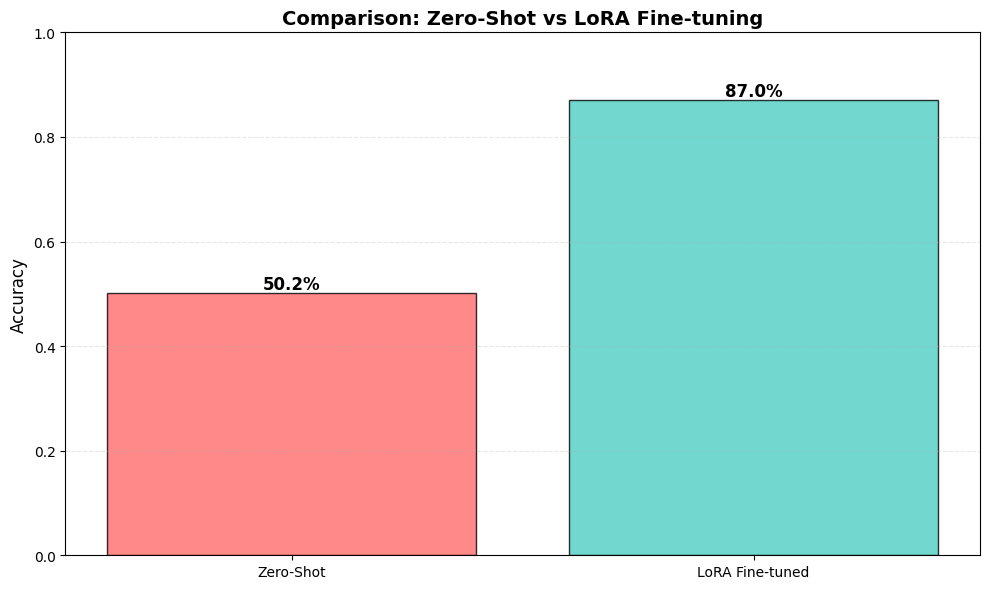


Improvement from Fine-tuning: +36.8%


In [ ]:
methods = ['Zero-Shot', 'LoRA Fine-tuned']
accuracies = [zero_shot_accuracy, lora_accuracy]
colors = ['#FF6B6B', '#4ECDC4']

plt.figure(figsize=(10, 6))
bars = plt.bar(methods, accuracies, color=colors, alpha=0.8, edgecolor='black')

for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.1%}',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.ylabel('Accuracy', fontsize=12)
plt.title('Comparison: Zero-Shot vs LoRA Fine-tuning', fontsize=14, fontweight='bold')
plt.ylim(0, 1.0)
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print(f"\nImprovement from Fine-tuning: +{(lora_accuracy - zero_shot_accuracy):.1%}")

## Save Your LoRA Adapter

One of the best features of LoRA: the adapter is **tiny** (usually just a few MB)!

In [ ]:
output_dir = "./lora_imdb_adapter"
peft_model.save_pretrained(output_dir)

import os
adapter_size = sum(os.path.getsize(os.path.join(output_dir, f))
                   for f in os.listdir(output_dir) if os.path.isfile(os.path.join(output_dir, f)))

print(f" LoRA adapter saved to: {output_dir}")
print(f" Adapter size: {adapter_size / (1024**2):.2f} MB")

 LoRA adapter saved to: ./lora_imdb_adapter
 Adapter size: 7.34 MB


### Storage comparison with the base model

In [ ]:
print(f"Total parameters of the base model (before LoRA): {total_params:,}")

Total parameters of the base model (before LoRA): 66,955,010


In [ ]:
full_model_size_bytes = total_params * 4
full_model_size_mb = full_model_size_bytes / (1024 * 1024)

print(f"Full model size: {full_model_size_mb:.2f} MB")

lora_adapter_size_mb = adapter_size / (1024 * 1024)

print(f"LoRA adapter size: {lora_adapter_size_mb:.2f} MB")

Full model size: 255.41 MB
LoRA adapter size: 7.34 MB


In [ ]:
size_difference_mb = full_model_size_mb - lora_adapter_size_mb
size_ratio = full_model_size_mb / lora_adapter_size_mb

print(f"\nDifference (Full Model - LoRA Adapter): {size_difference_mb:.2f} MB")
print(f"Ratio (Full Model / LoRA Adapter): {size_ratio:.2f}x smaller")


Difference (Full Model - LoRA Adapter): 248.08 MB
Ratio (Full Model / LoRA Adapter): 34.81x smaller


## Key Takeaways

### What We Learned:
1. **Zero-Shot**: Quick but less accurate for specific tasks
2. **Few-Shot**: Better with examples in the prompt (more effective with generative models)
3. **LoRA Fine-tuning**: Best accuracy with minimal training cost

### Why LoRA is Powerful:
- Trains only ~3% of parameters
- 10-100x faster than full fine-tuning
- Adapters are tiny (few MB vs GB)
- Can have multiple adapters for different tasks
- Works on consumer GPUs (even free Colab!)

### Next Steps:
- Try different values for `r` (rank) and see how it affects performance
- Experiment with different `target_modules`
- Use more training data for better results
- Try other PEFT methods like DoRA

---